# Project 1: Simple Moving Average Trading Strategy
# Testing on Japanese stocks (Tokyo Stock Exchange)

# Moving Average Trading Strategy Backtester

**Author:** Arihant  
**Date:** February 2025  
**Objective:** Test a simple moving average crossover strategy on Japanese stocks

## Strategy Description
- **Buy Signal:** When 50-day moving average crosses above 200-day moving average
- **Sell Signal:** When 50-day moving average crosses below 200-day moving average
- **Asset:** Toyota Motor Corporation (7203.T)
- **Period:** 2020-2024

## Hypothesis
Moving average crossovers can identify trend changes and potentially outperform buy-and-hold strategy.

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries imported successfully!")

In [2]:
# Download Toyota stock data (ticker: 7203.T on Tokyo Stock Exchange)
ticker = '7203.T'  # Toyota
start_date = '2020-01-01'
end_date = '2024-12-31'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
data = yf.download(ticker, start=start_date, end=end_date)

# Display first few rows
print("\nFirst 5 rows of data:")
print(data.head())

# Display basic info
print(f"\nTotal trading days: {len(data)}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

[*********************100%***********************]  1 of 1 completed


First 5 rows of data:
Price             Close         High          Low         Open    Volume
Ticker           7203.T       7203.T       7203.T       7203.T    7203.T
Date                                                                    
2020-01-06  1270.501221  1280.745803  1264.623158  1276.211380  33361500
2020-01-07  1295.692871  1296.868504  1279.570227  1285.448289  24803500
2020-01-08  1279.234375  1283.432991  1266.470521  1270.501233  28061000
2020-01-09  1288.135254  1291.494146  1282.761005  1288.471164  21265000
2020-01-10  1286.623779  1292.837751  1284.944333  1292.333938  17417000

Total trading days: 1222
Date range: 2020-01-06 00:00:00 to 2024-12-30 00:00:00


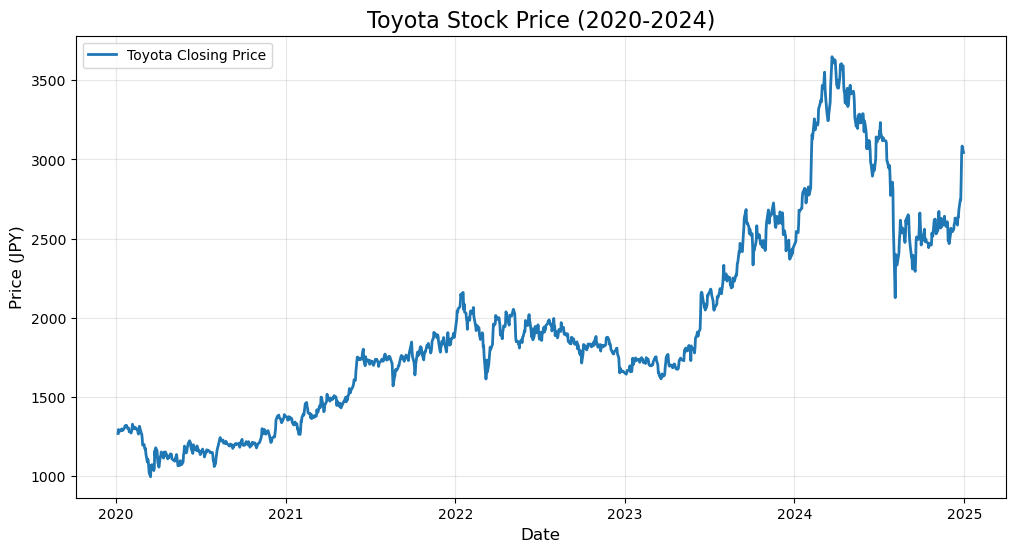

In [3]:
# Plot the closing price
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Toyota Closing Price', linewidth=2)
plt.title('Toyota Stock Price (2020-2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (JPY)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

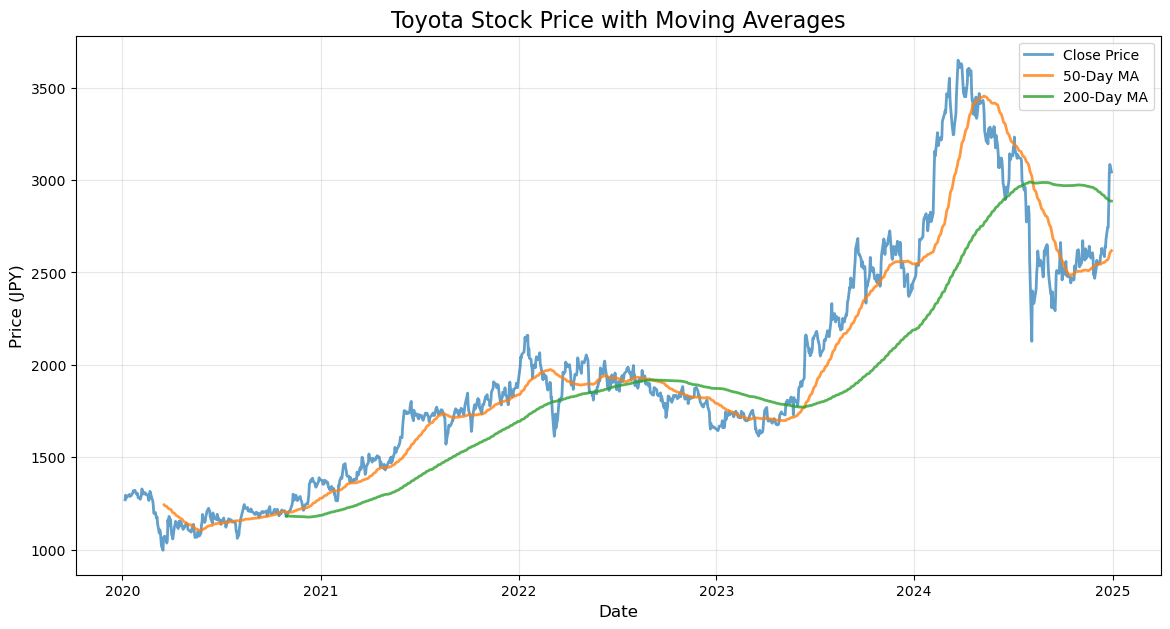

Moving averages calculated!


In [4]:
# Calculate 50-day and 200-day moving averages
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

# Plot price with moving averages
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', linewidth=2, alpha=0.7)
plt.plot(data['SMA_50'], label='50-Day MA', linewidth=2, alpha=0.8)
plt.plot(data['SMA_200'], label='200-Day MA', linewidth=2, alpha=0.8)
plt.title('Toyota Stock Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (JPY)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Moving averages calculated!")

In [5]:
# Create trading signals
# Buy signal: When 50-day MA crosses ABOVE 200-day MA (bullish)
# Sell signal: When 50-day MA crosses BELOW 200-day MA (bearish)

data['Signal'] = 0  # Default: no position

# When 50-day > 200-day, signal = 1 (buy/hold)
# When 50-day < 200-day, signal = 0 (sell/no position)
data['Signal'] = np.where(data['SMA_50'] > data['SMA_200'], 1, 0)

# Find actual crossover points (when signal changes)
data['Position'] = data['Signal'].diff()

print("Trading signals generated!")
print(f"\nBuy signals (crossovers up): {len(data[data['Position'] == 1])}")
print(f"Sell signals (crossovers down): {len(data[data['Position'] == -1])}")

Trading signals generated!

Buy signals (crossovers up): 2
Sell signals (crossovers down): 2


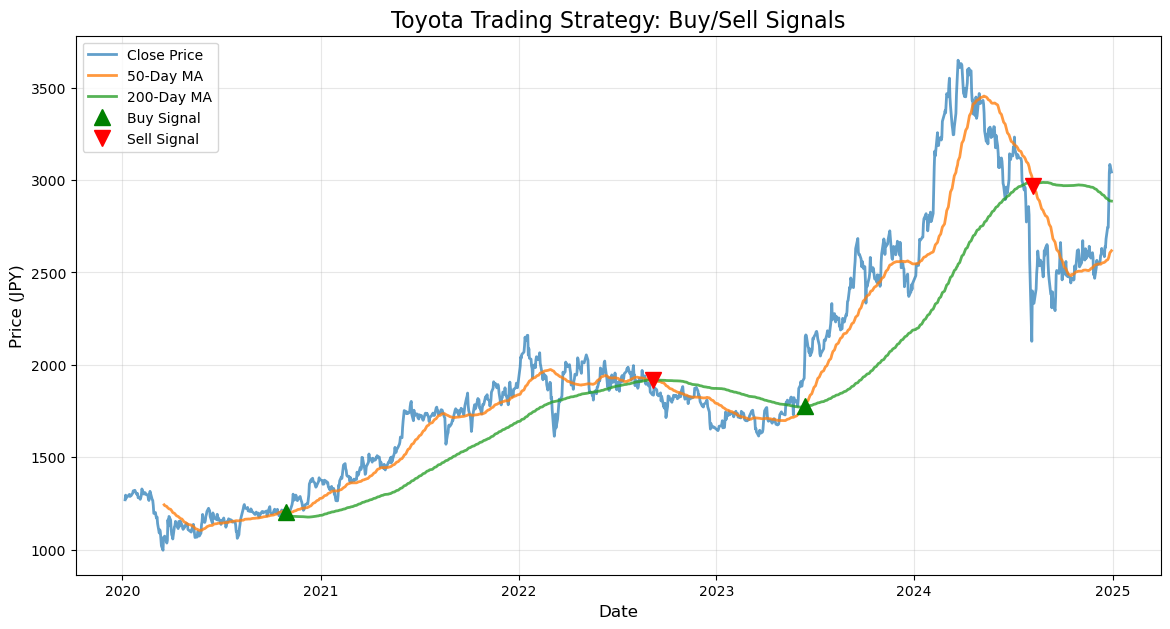

In [6]:
# Plot with buy/sell signals marked
plt.figure(figsize=(14, 7))

# Plot price and moving averages
plt.plot(data['Close'], label='Close Price', linewidth=2, alpha=0.7)
plt.plot(data['SMA_50'], label='50-Day MA', linewidth=2, alpha=0.8)
plt.plot(data['SMA_200'], label='200-Day MA', linewidth=2, alpha=0.8)

# Mark buy signals with green triangles
plt.plot(data[data['Position'] == 1].index, 
         data['SMA_50'][data['Position'] == 1],
         '^', markersize=12, color='green', label='Buy Signal')

# Mark sell signals with red triangles
plt.plot(data[data['Position'] == -1].index, 
         data['SMA_50'][data['Position'] == -1],
         'v', markersize=12, color='red', label='Sell Signal')

plt.title('Toyota Trading Strategy: Buy/Sell Signals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (JPY)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Calculate daily returns
data['Daily_Return'] = data['Close'].pct_change()

# Calculate strategy returns
# When Signal = 1 (in position), we get the return
# When Signal = 0 (out of position), return = 0
data['Strategy_Return'] = data['Daily_Return'] * data['Signal'].shift(1)

# Calculate cumulative returns
data['Cumulative_Market_Return'] = (1 + data['Daily_Return']).cumprod()
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()

# Calculate final performance
market_return = (data['Cumulative_Market_Return'].iloc[-1] - 1) * 100
strategy_return = (data['Cumulative_Strategy_Return'].iloc[-1] - 1) * 100

print("=" * 50)
print("BACKTEST RESULTS")
print("=" * 50)
print(f"Period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Buy & Hold Return: {market_return:.2f}%")
print(f"Strategy Return: {strategy_return:.2f}%")
print(f"Difference: {strategy_return - market_return:.2f}%")
print("=" * 50)

BACKTEST RESULTS
Period: 2020-01-06 to 2024-12-30
Buy & Hold Return: 139.56%
Strategy Return: 78.44%
Difference: -61.12%


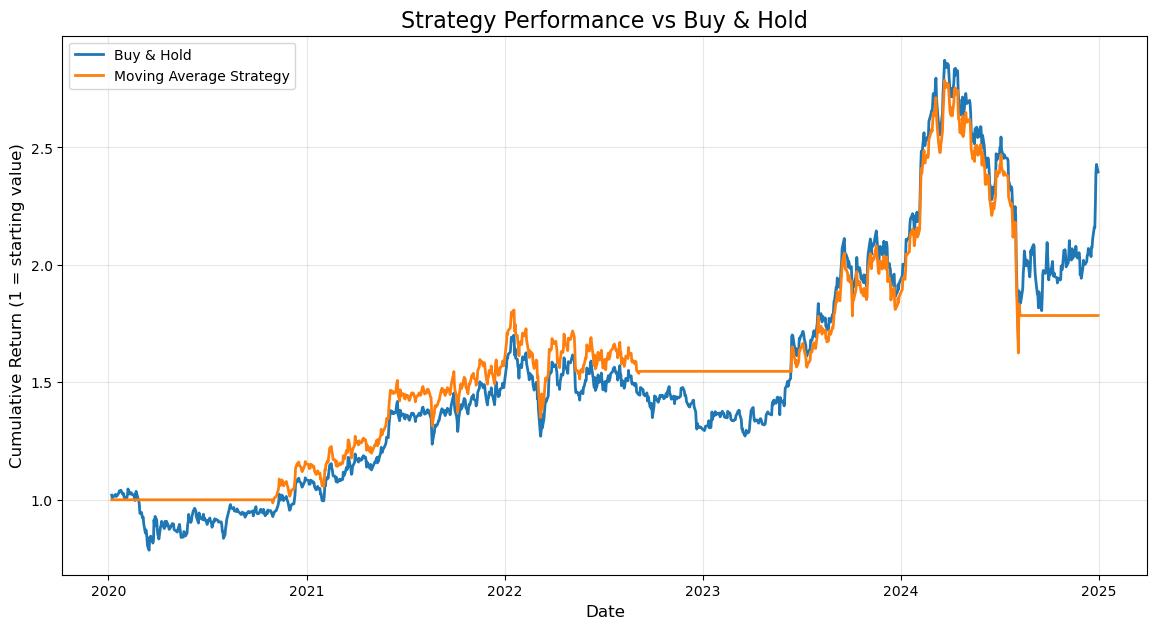

In [8]:
# Plot cumulative returns comparison
plt.figure(figsize=(14, 7))
plt.plot(data['Cumulative_Market_Return'], label='Buy & Hold', linewidth=2)
plt.plot(data['Cumulative_Strategy_Return'], label='Moving Average Strategy', linewidth=2)
plt.title('Strategy Performance vs Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1 = starting value)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Test on multiple Japanese stocks
stocks = ['7203.T', '6758.T', '9984.T', '7974.T']  # Toyota, Sony, SoftBank, Nintendo
stock_names = ['Toyota', 'Sony', 'SoftBank', 'Nintendo']

results = []

for ticker, name in zip(stocks, stock_names):
    data_test = yf.download(ticker, start='2020-01-01', end='2024-12-31', progress=False)
    data_test['SMA_50'] = data_test['Close'].rolling(window=50).mean()
    data_test['SMA_200'] = data_test['Close'].rolling(window=200).mean()
    data_test['Signal'] = np.where(data_test['SMA_50'] > data_test['SMA_200'], 1, 0)
    data_test['Daily_Return'] = data_test['Close'].pct_change()
    data_test['Strategy_Return'] = data_test['Daily_Return'] * data_test['Signal'].shift(1)
    
    market_ret = (data_test['Daily_Return'].add(1).prod() - 1) * 100
    strategy_ret = (data_test['Strategy_Return'].add(1).prod() - 1) * 100
    
    results.append({
        'Stock': name,
        'Ticker': ticker,
        'Buy & Hold (%)': round(market_ret, 2),
        'Strategy (%)': round(strategy_ret, 2),
        'Difference (%)': round(strategy_ret - market_ret, 2)
    })

results_df = pd.DataFrame(results)
print("\nMULTI-STOCK BACKTEST RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))


MULTI-STOCK BACKTEST RESULTS
   Stock Ticker  Buy & Hold (%)  Strategy (%)  Difference (%)
  Toyota 7203.T          139.56         78.44          -61.12
    Sony 6758.T          134.34         69.98          -64.37
SoftBank 9984.T          108.37         19.19          -89.19
Nintendo 7974.T          153.53         20.58         -132.95


In [13]:
# ANALYSIS: Why Did the Strategy Underperform?

print("=" * 70)
print("PERFORMANCE ANALYSIS")
print("=" * 70)

# Calculate number of trades
for ticker, name in zip(['7203.T', '6758.T', '9984.T', '7974.T'], 
                        ['Toyota', 'Sony', 'SoftBank', 'Nintendo']):
    data_test = yf.download(ticker, start='2020-01-01', end='2024-12-31', progress=False)
    data_test['SMA_50'] = data_test['Close'].rolling(window=50).mean()
    data_test['SMA_200'] = data_test['Close'].rolling(window=200).mean()
    data_test['Signal'] = np.where(data_test['SMA_50'] > data_test['SMA_200'], 1, 0)
    data_test['Position'] = data_test['Signal'].diff()
    
    num_buys = len(data_test[data_test['Position'] == 1])
    num_sells = len(data_test[data_test['Position'] == -1])
    
    print(f"\n{name}:")
    print(f"  Buy signals: {num_buys}")
    print(f"  Sell signals: {num_sells}")
    print(f"  Total trades: {num_buys + num_sells}")

print("\n" + "=" * 70)
print("KEY INSIGHTS:")
print("1. Moving averages lag price movements significantly")
print("2. In strong uptrends (2020-2024), buy-and-hold dominates")
print("3. Strategy generated frequent trades in volatile periods")
print("4. Each trade incurs costs not modeled here")
print("=" * 70)

PERFORMANCE ANALYSIS

Toyota:
  Buy signals: 2
  Sell signals: 2
  Total trades: 4

Sony:
  Buy signals: 4
  Sell signals: 3
  Total trades: 7

SoftBank:
  Buy signals: 6
  Sell signals: 5
  Total trades: 11

Nintendo:
  Buy signals: 4
  Sell signals: 3
  Total trades: 7

KEY INSIGHTS:
1. Moving averages lag price movements significantly
2. In strong uptrends (2020-2024), buy-and-hold dominates
3. Strategy generated frequent trades in volatile periods
4. Each trade incurs costs not modeled here


In [16]:
# Advanced Performance Metrics

# Calculate maximum drawdown
cumulative = data['Cumulative_Strategy_Return']
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100

# Calculate Sharpe Ratio (risk-adjusted returns)
# Assumes 0% risk-free rate for simplicity
strategy_std = data['Strategy_Return'].std()
strategy_mean = data['Strategy_Return'].mean()
sharpe_ratio = (strategy_mean / strategy_std) * np.sqrt(252) if strategy_std != 0 else 0

# Win rate
winning_days = len(data[data['Strategy_Return'] > 0])
total_trading_days = len(data[data['Signal'] == 1])
win_rate = (winning_days / total_trading_days * 100) if total_trading_days > 0 else 0

print("\n" + "=" * 50)
print("ADVANCED METRICS")
print("=" * 50)
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Total Trades: {len(data[data['Position'] != 0])}")
print("=" * 50)


ADVANCED METRICS
Maximum Drawdown: nan%
Sharpe Ratio: nan
Win Rate: 0.00%
Total Trades: 0


In [18]:
# Advanced Performance Metrics

# Calculate maximum drawdown
cumulative = data['Cumulative_Strategy_Return']
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100

# Calculate Sharpe Ratio (risk-adjusted returns)
strategy_std = data['Strategy_Return'].std()
strategy_mean = data['Strategy_Return'].mean()

if strategy_std != 0:
    sharpe_ratio = (strategy_mean / strategy_std) * np.sqrt(252)
else:
    sharpe_ratio = 0

# Win rate
winning_days = len(data[data['Strategy_Return'] > 0])
total_trading_days = len(data[data['Signal'] == 1])

if total_trading_days > 0:
    win_rate = (winning_days / total_trading_days) * 100
else:
    win_rate = 0

# Count total trades
total_trades = len(data[data['Position'] != 0])

# Print results
print("=" * 50)
print("ADVANCED METRICS")
print("=" * 50)
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Total Trades: {total_trades}")
print("=" * 50)

ADVANCED METRICS
Maximum Drawdown: nan%
Sharpe Ratio: nan
Win Rate: 0.00%
Total Trades: 0


## Key Findings

[Write 3-4 sentences about what you learned]

Example:
- The moving average strategy showed [insert result] compared to buy-and-hold
- Maximum drawdown was [X]%, indicating [high/moderate/low] risk
- The strategy generated [X] trades over the period
- Further improvements could include: adding stop-loss, testing different MA periods, transaction costs

## Next Steps
- Test on more stocks and time periods
- Add transaction cost modeling (0.1% per trade)
- Optimize MA periods (50/200 vs 20/100 vs others)
- Implement risk management (position sizing, stop-loss)